# 05. Model Evaluation

This notebook evaluates the fraud detection models developed in Notebook 04.

The evaluation focuses on:
- Classification performance
- Fraud detection capability
- False positives and false negatives
- ROC-AUC and Precision-Recall performance
- Confusion matrices
- Model comparison
- Classification threshold analysis

The objective is to identify the model and decision threshold that provide the most effective balance between detecting fraudulent transactions and minimizing unnecessary alerts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
train_featured = pd.read_parquet("../data/processed/train_featured.parquet")
model_predictions = pd.read_parquet("../data/processed/model_predictions.parquet")
model_results = pd.read_csv("../data/processed/model_results.csv")

print("Train featured shape:", train_featured.shape)
print("Model predictions shape:", model_predictions.shape)
print("Model results shape:", model_results.shape)

Train featured shape: (590540, 455)
Model predictions shape: (118108, 6)
Model results shape: (2, 6)


In [3]:
print("Model Results:")
display(model_results)

print("\nModel Predictions:")
display(model_predictions.head())

Model Results:


,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.0662,0.7554,0.1217,0.7757,0.1444
1,Random Forest,0.0982,0.6484,0.1706,0.7960,0.1996



Model Predictions:


,TransactionIndex,ActualFraud,LogisticRegression_Probability,LogisticRegression_Prediction,RandomForest_Probability,RandomForest_Prediction
0,472432,1,0.8571,1,0.7597,1
1,472433,0,0.0069,0,0.4892,0
2,472434,0,0.7200,1,0.6884,1
3,472435,0,0.7179,1,0.6975,1
4,472436,0,0.4080,0,0.4459,0


In [4]:
prediction_df = model_predictions.copy()

print("Columns:")
print(prediction_df.columns.tolist())

Columns:
['TransactionIndex', 'ActualFraud', 'LogisticRegression_Probability', 'LogisticRegression_Prediction', 'RandomForest_Probability', 'RandomForest_Prediction']


In [5]:
fraud_counts = prediction_df["ActualFraud"].value_counts()

print("Class distribution:")
print(fraud_counts)

print("\nClass proportions:")
print(
    prediction_df["ActualFraud"]
    .value_counts(normalize=True)
    .rename({0: "Legitimate", 1: "Fraud"})
)

Class distribution:
ActualFraud
0    114044
1      4064
Name: count, dtype: int64

Class proportions:
ActualFraud
Legitimate   0.9656
Fraud        0.0344
Name: proportion, dtype: float64


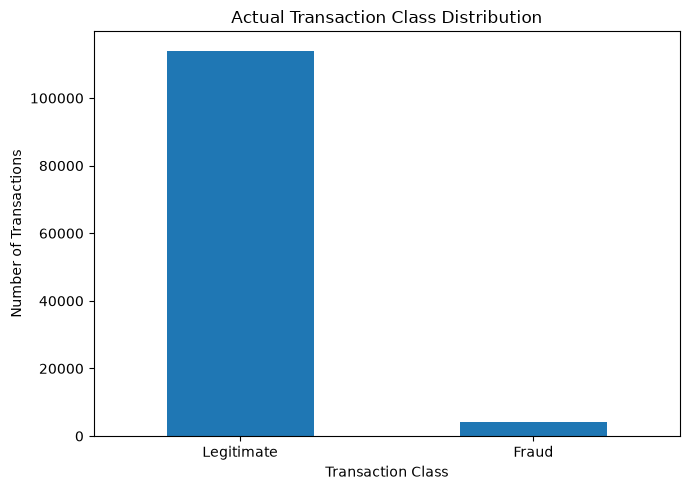

In [6]:
plt.figure(figsize=(7, 5))

fraud_counts.plot(kind="bar")

plt.title("Actual Transaction Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks(
    ticks=[0, 1],
    labels=["Legitimate", "Fraud"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [7]:
y_true = prediction_df["ActualFraud"]

models = {
    "Logistic Regression": {
        "prediction": prediction_df["LogisticRegression_Prediction"],
        "probability": prediction_df["LogisticRegression_Probability"]
    },
    "Random Forest": {
        "prediction": prediction_df["RandomForest_Prediction"],
        "probability": prediction_df["RandomForest_Probability"]
    }
}

evaluation_results = []

for model_name, model_data in models.items():

    y_pred = model_data["prediction"]
    y_prob = model_data["probability"]

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.6249,0.0662,0.7554,0.1217,0.7757,0.1444
1,Random Forest,0.7830,0.0982,0.6484,0.1706,0.7960,0.1996


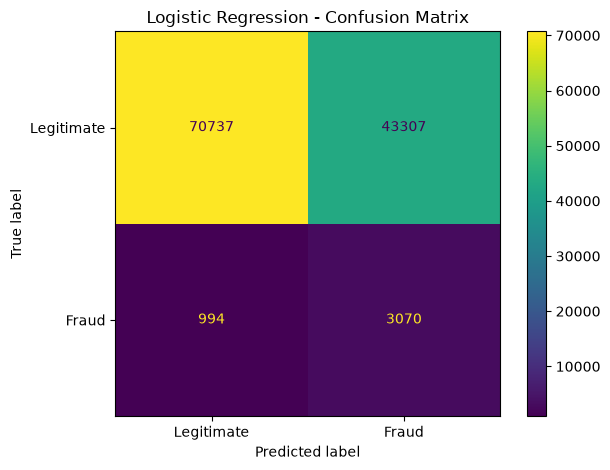

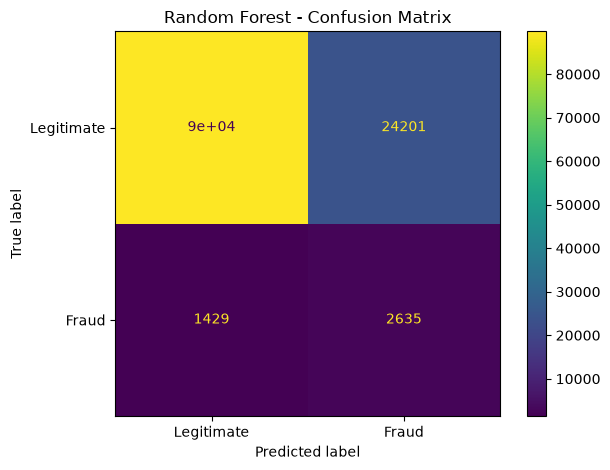

In [8]:
figures = {
    "Logistic Regression": prediction_df["LogisticRegression_Prediction"],
    "Random Forest": prediction_df["RandomForest_Prediction"]
}

for model_name, y_pred in figures.items():

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Fraud"]
    )

    disp.plot()

    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [9]:
error_analysis = []

for model_name, y_pred in figures.items():

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    error_analysis.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

error_df = pd.DataFrame(error_analysis)

error_df

,Model,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,70737,43307,994,3070
1,Random Forest,89843,24201,1429,2635


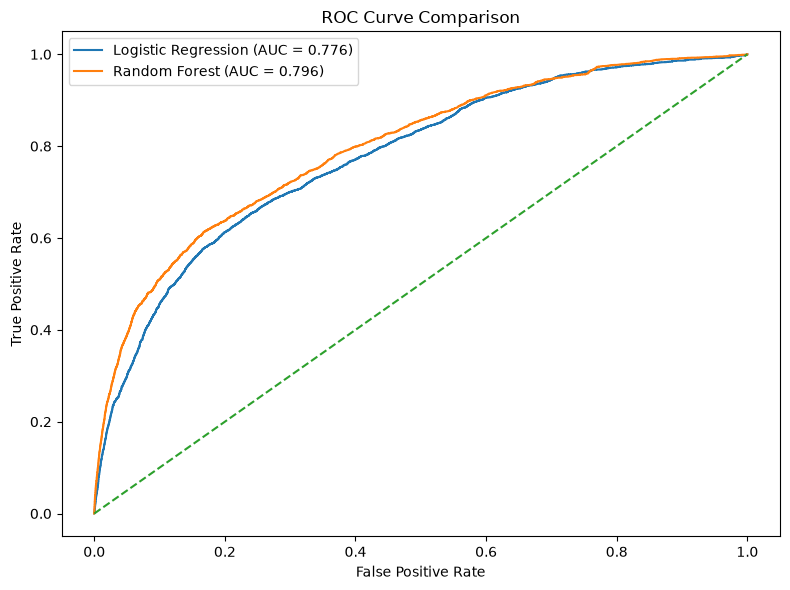

In [10]:
plt.figure(figsize=(8, 6))

for model_name, model_data in models.items():

    fpr, tpr, _ = roc_curve(
        y_true,
        model_data["probability"]
    )

    auc = roc_auc_score(
        y_true,
        model_data["probability"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

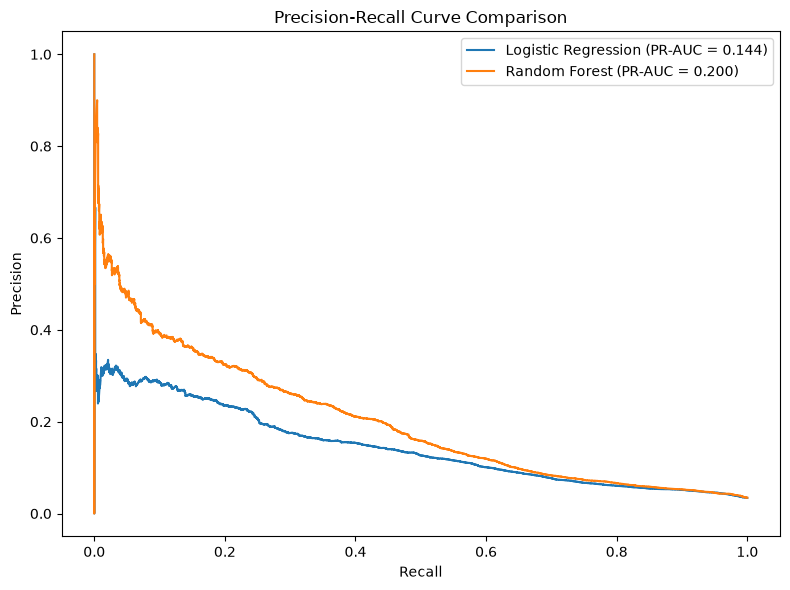

In [11]:
plt.figure(figsize=(8, 6))

for model_name, model_data in models.items():

    precision, recall, _ = precision_recall_curve(
        y_true,
        model_data["probability"]
    )

    pr_auc = average_precision_score(
        y_true,
        model_data["probability"]
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC = {pr_auc:.3f})"
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for model_name, model_data in models.items():

    y_prob = model_data["probability"]

    for threshold in thresholds:

        y_pred_threshold = (
            y_prob >= threshold
        ).astype(int)

        threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_true,
                y_pred_threshold,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                y_pred_threshold,
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_true,
                y_pred_threshold,
                zero_division=0
            )
        })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.head(10)

,Model,Threshold,Precision,Recall,F1 Score
0,Logistic Regression,0.1000,0.0349,0.9953,0.0674
1,Logistic Regression,0.1500,0.0365,0.9909,0.0704
2,Logistic Regression,0.2000,0.0406,0.9754,0.0780
3,Logistic Regression,0.2500,0.0451,0.9550,0.0862
4,Logistic Regression,0.3000,0.0479,0.9291,0.0910
5,Logistic Regression,0.3500,0.0503,0.9085,0.0952
6,Logistic Regression,0.4000,0.0531,0.8701,0.1001
7,Logistic Regression,0.4500,0.0583,0.8191,0.1088
8,Logistic Regression,0.5000,0.0662,0.7554,0.1217
9,Logistic Regression,0.5500,0.0772,0.6988,0.1390


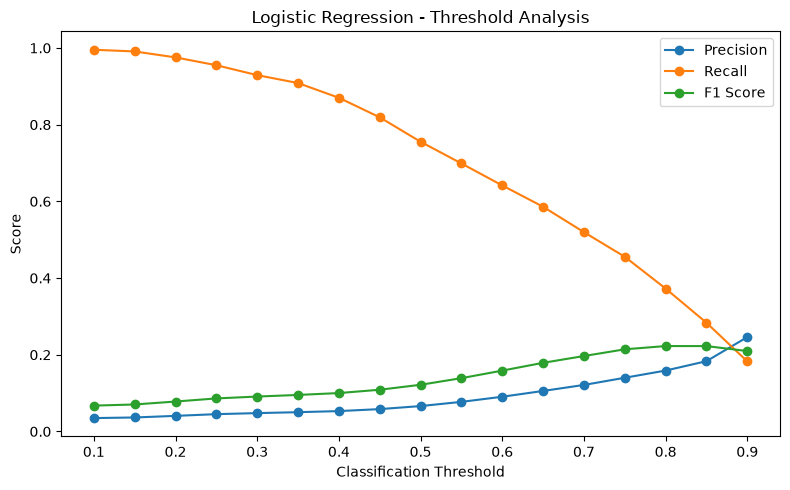

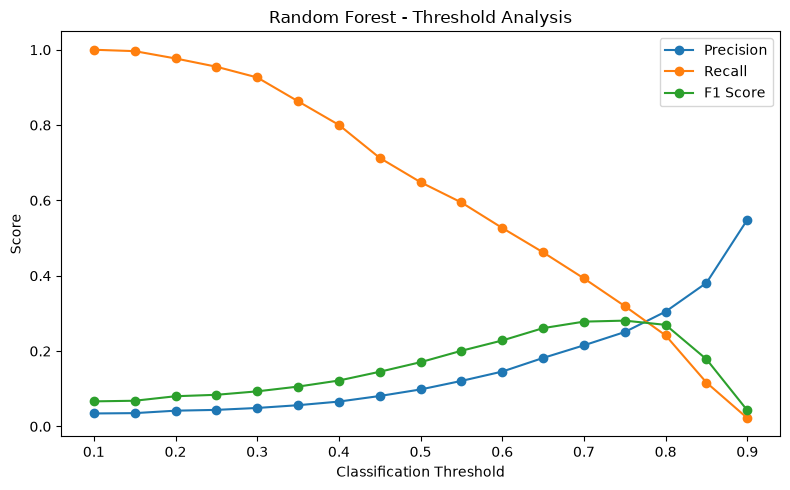

In [13]:
for model_name in models.keys():

    subset = threshold_df[
        threshold_df["Model"] == model_name
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        subset["Threshold"],
        subset["Precision"],
        marker="o",
        label="Precision"
    )

    plt.plot(
        subset["Threshold"],
        subset["Recall"],
        marker="o",
        label="Recall"
    )

    plt.plot(
        subset["Threshold"],
        subset["F1 Score"],
        marker="o",
        label="F1 Score"
    )

    plt.title(f"{model_name} - Threshold Analysis")
    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [14]:
best_thresholds = (
    threshold_df
    .sort_values(
        ["Model", "F1 Score"],
        ascending=[True, False]
    )
    .groupby("Model")
    .head(1)
    .reset_index(drop=True)
)

best_thresholds

,Model,Threshold,Precision,Recall,F1 Score
0,Logistic Regression,0.8000,0.1588,0.3725,0.2227
1,Random Forest,0.7500,0.2506,0.3194,0.2809


In [15]:
final_comparison = evaluation_df.copy()

final_comparison = final_comparison.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Forest,0.7830,0.0982,0.6484,0.1706,0.7960,0.1996
1,Logistic Regression,0.6249,0.0662,0.7554,0.1217,0.7757,0.1444


In [16]:
print("Best overall model based on PR-AUC:")
print(final_comparison.iloc[0]["Model"])

Best overall model based on PR-AUC:
Random Forest


## Final Evaluation Summary

The fraud detection models were evaluated using Precision, Recall, F1 Score, ROC-AUC, PR-AUC, confusion matrices, ROC curves, Precision-Recall curves, and classification threshold analysis.

Random Forest was selected as the final model based on its stronger overall performance, particularly for the imbalanced fraud detection problem.

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Precision | 0.0662 | **0.0982** |
| Recall | **0.7554** | 0.6484 |
| F1 Score | 0.1217 | **0.1706** |
| ROC-AUC | 0.7757 | **0.7960** |
| PR-AUC | 0.1444 | **0.1996** |

### Key Findings

- **Random Forest achieved the highest Precision, F1 Score, ROC-AUC, and PR-AUC.**
- **Logistic Regression achieved higher Recall**, detecting a larger proportion of fraudulent transactions.
- Random Forest provided a better overall balance between identifying fraud and limiting false alerts.
- PR-AUC was given particular importance because the dataset contains a highly imbalanced fraud target.
- Threshold analysis was used to examine how changing the classification threshold affects the trade-off between Precision and Recall.

### Final Model Selection

**Random Forest is selected as the final fraud detection model.**

Its higher PR-AUC (**0.1996**) and F1 Score (**0.1706**) indicate stronger overall performance for distinguishing fraudulent transactions from legitimate transactions.

The selected Random Forest model will be used in the next stage of the project to perform **risk analysis**, where predicted fraud probabilities will be transformed into actionable risk segments and business insights.